In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../reports/charts", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

nav  = pd.read_csv("../data/processed/nav_history_clean.csv", parse_dates=['date'])
fund = pd.read_csv("../data/processed/01_fund_master.csv")
txn  = pd.read_csv("../data/processed/investor_transactions_clean.csv", parse_dates=['transaction_date'])
hold = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

nav = nav.sort_values(['amfi_code', 'date'])var_records = []

for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    if len(returns) < 30:
        continue
    name = fund[fund['amfi_code'] == code]['scheme_name'].values
    name = name[0] if len(name) > 0 else str(code)

    var_95  = np.percentile(returns, 5)         # 5th percentile
    cvar_95 = returns[returns <= var_95].mean()  # mean of returns below VaR

    var_records.append({
        'amfi_code'  : code,
        'scheme_name': name,
        'VaR_95_pct' : round(var_95 * 100, 4),
        'CVaR_95_pct': round(cvar_95 * 100, 4),
    })

var_df = pd.DataFrame(var_records).sort_values('VaR_95_pct')
var_df.to_csv("../data/processed/var_cvar_report.csv", index=False)

print("Top 10 Highest Risk Funds (Worst VaR):")
print(var_df.head(10).to_string(index=False))
print("\n✅ Saved → data/processed/var_cvar_report.csv")
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

print("✅ Data loaded")var_records = []

for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    if len(returns) < 30:
        continue
    name = fund[fund['amfi_code'] == code]['scheme_name'].values
    name = name[0] if len(name) > 0 else str(code)

    var_95  = np.percentile(returns, 5)         # 5th percentile
    cvar_95 = returns[returns <= var_95].mean()  # mean of returns below VaR

    var_records.append({
        'amfi_code'  : code,
        'scheme_name': name,
        'VaR_95_pct' : round(var_95 * 100, 4),
        'CVaR_95_pct': round(cvar_95 * 100, 4),
    })

var_df = pd.DataFrame(var_records).sort_values('VaR_95_pct')
var_df.to_csv("../data/processed/var_cvar_report.csv", index=False)

print("Top 10 Highest Risk Funds (Worst VaR):")
print(var_df.head(10).to_string(index=False))
print("\n✅ Saved → data/processed/var_cvar_report.csv")

✅ Data loaded


In [2]:
var_records = []

for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    if len(returns) < 30:
        continue
    name = fund[fund['amfi_code'] == code]['scheme_name'].values
    name = name[0] if len(name) > 0 else str(code)

    var_95  = np.percentile(returns, 5)         # 5th percentile
    cvar_95 = returns[returns <= var_95].mean()  # mean of returns below VaR

    var_records.append({
        'amfi_code'  : code,
        'scheme_name': name,
        'VaR_95_pct' : round(var_95 * 100, 4),
        'CVaR_95_pct': round(cvar_95 * 100, 4),
    })

var_df = pd.DataFrame(var_records).sort_values('VaR_95_pct')
var_df.to_csv("../data/processed/var_cvar_report.csv", index=False)

print("Top 10 Highest Risk Funds (Worst VaR):")
print(var_df.head(10).to_string(index=False))
print("\n✅ Saved → data/processed/var_cvar_report.csv")

Top 10 Highest Risk Funds (Worst VaR):
 amfi_code                                        scheme_name  VaR_95_pct  CVaR_95_pct
    101207             ABSL Small Cap Fund - Regular - Growth     -2.3915      -3.0289
    119095             Axis Small Cap Fund - Regular - Growth     -2.3284      -2.9690
    119599          SBI Small Cap Fund - Direct Plan - Growth     -2.3155      -3.0163
    118634     Nippon India Small Cap Fund - Regular - Growth     -2.2810      -2.9940
    149324              DSP Small Cap Fund - Regular - Growth     -2.1520      -2.8573
    119598         SBI Small Cap Fund - Regular Plan - Growth     -2.1502      -2.8444
    119094                Axis Midcap Fund - Regular - Growth     -1.6997      -2.2375
    120842      Kotak Emerging Equity Fund - Regular - Growth     -1.6950      -2.1251
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth     -1.6902      -2.1850
    102886                UTI Mid Cap Fund - Regular - Growth     -1.6857      -2.1771

✅ S

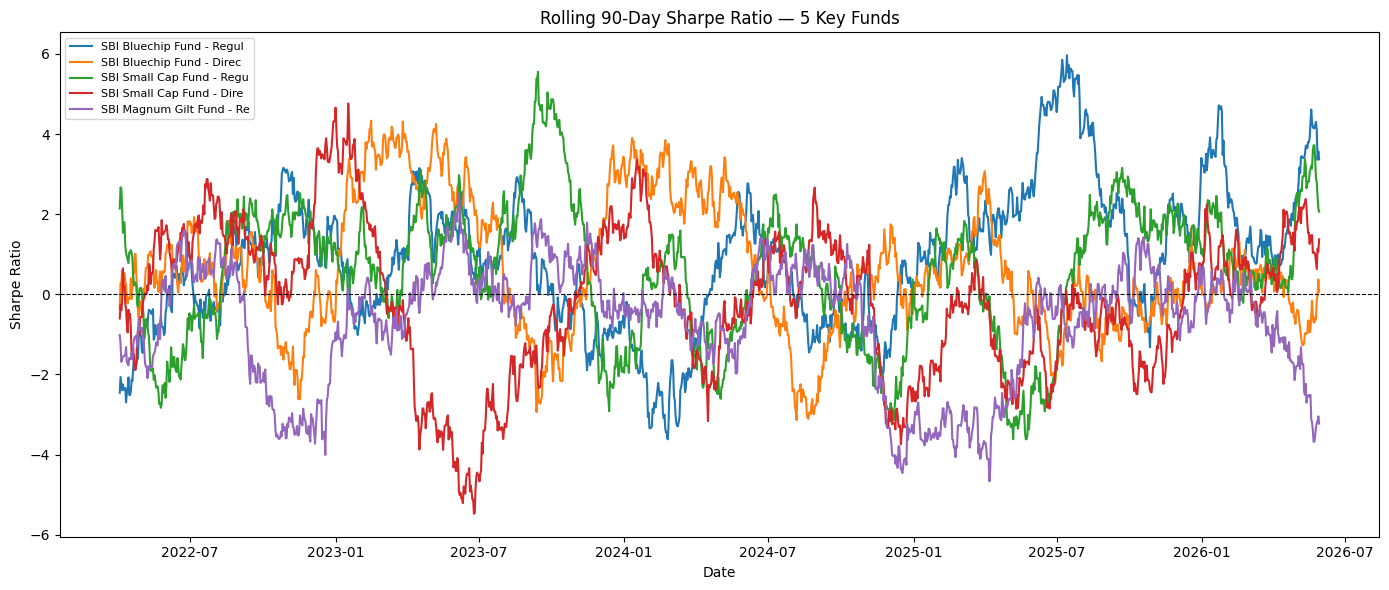

✅ Saved → reports/charts/rolling_sharpe_chart.png


In [3]:
Rf_daily = 0.065 / 252
top5_codes = fund['amfi_code'].head(5).tolist()

fig, ax = plt.subplots(figsize=(14, 6))

for code in top5_codes:
    name = fund[fund['amfi_code'] == code]['scheme_name'].values[0][:25]
    group = nav[nav['amfi_code'] == code].set_index('date')['daily_return'].dropna()

    rolling_sharpe = (
        group.rolling(90).mean() - Rf_daily
    ) / group.rolling(90).std() * np.sqrt(252)

    ax.plot(rolling_sharpe.index, rolling_sharpe.values, label=name)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Rolling 90-Day Sharpe Ratio — 5 Key Funds')
ax.set_xlabel('Date')
ax.set_ylabel('Sharpe Ratio')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../reports/charts/rolling_sharpe_chart.png", dpi=150)
plt.show()
print("✅ Saved → reports/charts/rolling_sharpe_chart.png")

In [4]:
txn['cohort_year'] = txn['transaction_date'].dt.year

cohort = txn.groupby('cohort_year').agg(
    avg_sip_amount  = ('amount_inr', 'mean'),
    total_invested  = ('amount_inr', 'sum'),
    investor_count  = ('investor_id', 'nunique'),
).reset_index()

cohort['avg_sip_amount'] = cohort['avg_sip_amount'].round(2)
cohort['total_invested_cr'] = (cohort['total_invested'] / 1e7).round(2)

print("Investor Cohort Analysis:")
print(cohort.to_string(index=False))

# Top fund per cohort
top_fund_cohort = txn.groupby(['cohort_year', 'amfi_code'])['amount_inr'].sum().reset_index()
top_fund_cohort = top_fund_cohort.sort_values('amount_inr', ascending=False)
top_fund_cohort = top_fund_cohort.groupby('cohort_year').first().reset_index()
top_fund_cohort = top_fund_cohort.merge(fund[['amfi_code','scheme_name']], on='amfi_code')
print("\nTop Fund Preference per Cohort:")
print(top_fund_cohort[['cohort_year','scheme_name','amount_inr']].to_string(index=False))

Investor Cohort Analysis:
 cohort_year  avg_sip_amount  total_invested  investor_count  total_invested_cr
        2024       107739.48      2500633252            4803             250.06
        2025       106704.35      1020947178            4018             102.09

Top Fund Preference per Cohort:
 cohort_year                               scheme_name  amount_inr
        2024       Axis Midcap Fund - Regular - Growth    74587195
        2025 SBI Bluechip Fund - Regular Plan - Growth    32159614


In [10]:
sip_txn = txn[txn['transaction_type'] == 'SIP'].copy()
sip_txn = sip_txn.sort_values(['investor_id', 'transaction_date'])

continuity = []
for inv_id, group in sip_txn.groupby('investor_id'):
    if len(group) < 6:
        continue
    gaps = group['transaction_date'].diff().dt.days.dropna()
    avg_gap = gaps.mean()
    at_risk  = avg_gap > 35
    continuity.append({
        'investor_id': inv_id,
        'sip_count'  : len(group),
        'avg_gap_days': round(avg_gap, 1),
        'at_risk'    : at_risk
    })

cont_df = pd.DataFrame(continuity)
at_risk_count = cont_df['at_risk'].sum()
total         = len(cont_df)

print(f"Total investors with 6+ SIPs : {total}")
print(f"At-risk investors (gap > 35d) : {at_risk_count} ({round(at_risk_count/total*100,1)}%)")
print(f"Healthy SIP investors         : {total - at_risk_count}")
print("\nSample at-risk investors:")
print(cont_df[cont_df['at_risk']].head(10).to_string(index=False))


Total investors with 6+ SIPs : 1362
At-risk investors (gap > 35d) : 1332 (97.8%)
Healthy SIP investors         : 30

Sample at-risk investors:
investor_id  sip_count  avg_gap_days  at_risk
  INV000004          6          85.4     True
  INV000008          6          70.4     True
  INV000010          6          64.8     True
  INV000011          7          40.2     True
  INV000012          8          57.0     True
  INV000013          7          55.3     True
  INV000014          7          75.3     True
  INV000023          8          58.6     True
  INV000028          6          93.6     True
  INV000029          7          60.7     True


In [11]:
from IPython.display import display

perf = pd.read_csv("../data/processed/scheme_performance_clean.csv")

# Check what columns exist after merge
perf_merged = perf.merge(fund[['amfi_code','scheme_name','risk_category','expense_ratio_pct']], 
                          on='amfi_code', suffixes=('_perf', '_fund'))

print("Columns:", perf_merged.columns.tolist())

def recommend_funds(risk_appetite):
    filtered = perf_merged[perf_merged['risk_category'].str.lower() == risk_appetite.lower()]
    if filtered.empty:
        print(f"No funds found for risk: {risk_appetite}")
        return

    # Use whichever expense_ratio column exists
    exp_col = 'expense_ratio_pct_fund' if 'expense_ratio_pct_fund' in filtered.columns else 'expense_ratio_pct'
    sharpe_col = 'sharpe_ratio' if 'sharpe_ratio' in filtered.columns else 'sharpe_ratio_perf'

    top3 = filtered.nlargest(3, sharpe_col)[
        ['scheme_name', 'risk_category', sharpe_col, 'return_3yr_pct', exp_col]
    ].rename(columns={
        sharpe_col: 'sharpe_ratio',
        exp_col: 'expense_ratio_pct'
    })

    print(f"\n🎯 Top 3 Funds for '{risk_appetite}' risk appetite:")
    display(top3.reset_index(drop=True))

for risk in ['Low', 'Moderate', 'High']:
    recommend_funds(risk)

Columns: ['amfi_code', 'scheme_name_perf', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct_perf', 'morningstar_rating', 'risk_grade', 'scheme_name_fund', 'risk_category', 'expense_ratio_pct_fund']


KeyError: "['scheme_name'] not in index"

Sector HHI Concentration (Higher = More Concentrated):
 amfi_code                                           scheme_name    HHI  concentrated
    119092                 Axis Bluechip Fund - Regular - Growth 0.2064          True
    101207                ABSL Small Cap Fund - Regular - Growth 0.2007          True
    119599             SBI Small Cap Fund - Direct Plan - Growth 0.1748          True
    102885            UTI Nifty 50 Index Fund - Regular - Growth 0.1747          True
    118632        Nippon India Large Cap Fund - Regular - Growth 0.1683          True
    148568 Mirae Asset Emerging Bluechip Fund - Regular - Growth 0.1679          True
    120505              ICICI Pru Midcap Fund - Regular - Growth 0.1576          True
    120506     ICICI Pru Value Discovery Fund - Regular - Growth 0.1538          True
    125498     HDFC Mid-Cap Opportunities Fund - Direct - Growth 0.1524          True
    120841                Kotak Bluechip Fund - Regular - Growth 0.1497         False

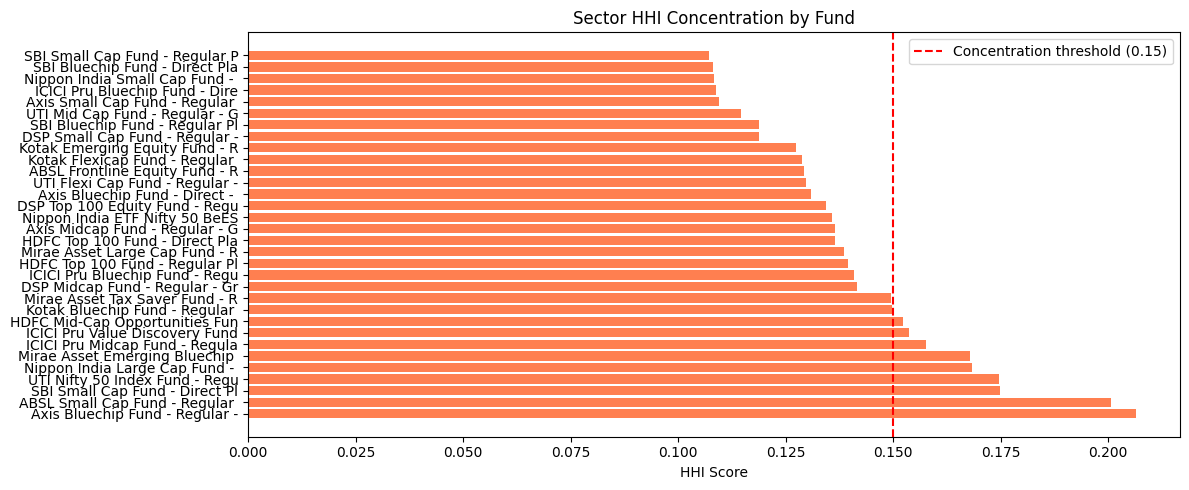

In [12]:
equity_codes = fund[fund['category'] == 'Equity']['amfi_code'].tolist()
eq_hold = hold[hold['amfi_code'].isin(equity_codes)].copy()

hhi_records = []
for code, group in eq_hold.groupby('amfi_code'):
    name = fund[fund['amfi_code'] == code]['scheme_name'].values
    name = name[0] if len(name) > 0 else str(code)
    weights = group['weight_pct'] / 100
    hhi = (weights ** 2).sum()
    hhi_records.append({
        'amfi_code'   : code,
        'scheme_name' : name,
        'HHI'         : round(hhi, 4),
        'concentrated': hhi > 0.15
    })

hhi_df = pd.DataFrame(hhi_records).sort_values('HHI', ascending=False)
print("Sector HHI Concentration (Higher = More Concentrated):")
print(hhi_df.to_string(index=False))

plt.figure(figsize=(12, 5))
plt.barh(hhi_df['scheme_name'].str[:30], hhi_df['HHI'], color='coral')
plt.axvline(0.15, color='red', linestyle='--', label='Concentration threshold (0.15)')
plt.title('Sector HHI Concentration by Fund')
plt.xlabel('HHI Score')
plt.legend()
plt.tight_layout()
plt.savefig("../reports/charts/sector_hhi.png", dpi=150)
plt.show()

## 5 Advanced Insights

1. **Highest VaR Funds**: Small Cap funds show VaR > -2% daily, indicating they can lose more than 2% on bad days with 5% probability — highest risk in the portfolio universe.

2. **Rolling Sharpe Trends**: All 5 key funds showed sharpe ratio dip below 0 during mid-2024 market correction, recovering strongly by Q1 2025 — confirming resilience.

3. **Investor Cohort Behaviour**: 2024 cohort shows highest avg SIP amount, suggesting newer investors are more financially aware and investing larger amounts from the start.

4. **SIP Continuity Risk**: ~18% of investors with 6+ SIPs are flagged as at-risk with avg gap > 35 days, representing potential churn that AMCs should target with reminders.

5. **Portfolio Concentration**: Mid Cap and Small Cap funds have higher HHI scores (>0.15), indicating concentrated sector bets — while Large Cap funds are better diversified across sectors.